In [ ]:
import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# os.environ['CUDA_VISIBLE_DEVICES'] = "0"
from transformers import Trainer, TrainingArguments
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from torch.utils.data import Dataset
from transformers import AutoModel
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import random
import torch
import json

c:\Users\user0\llm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Name of the pretrained model that will be fine-tuned
# It can be a huggingface model or a local model path
# Examples: "./Agent_resources/Models/roberta_ds_all", "FacebookAI/roberta-base"
pretrained_model = "FacebookAI/roberta-base"

In [ ]:
def contrastive_data_collator(features):
    """
    features is a list of dictionaries, where each dictionary is the output of one 
    __getitem__ call from our dataset.
    """
    batch = {}
    
    for key in ["t_i", "s_i", "s_j", "s_n"]:
        batch[key] = {
            "input_ids": torch.stack([f[key]["input_ids"] for f in features]),
            "attention_mask": torch.stack([f[key]["attention_mask"] for f in features])
        }
        
    return batch

In [ ]:
class PretokenizedSlideDataset(Dataset):
    def __init__(self, data_indices, tokenized_queries, tokenized_slides, is_train=True):
        """
        data_indices: List of [query_idx, s_i_idx, s_j_idx, [s_n_idx_1, ...]]
        tokenized_queries: Hugging Face BatchEncoding object for all queries
        tokenized_slides: Hugging Face BatchEncoding object for all slides
        """
        self.data = data_indices
        self.queries = tokenized_queries
        self.slides = tokenized_slides
        self.is_train = is_train

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Unpack the indices
        query_index, pos_indices, rel_indices, neg_indices = self.data[idx]
        
        # DYNAMIC SAMPLING: randomly pick a negative slide index for this specific epoch/batch
        if self.is_train:
            q_idx = query_index
            pos_idx = random.choice(pos_indices)
            rel_idx = random.choice(rel_indices)
            neg_idx = random.choice(neg_indices)
        else:
            q_idx = query_index
            pos_idx = pos_indices[0]
            rel_idx = rel_indices[0]
            neg_idx = neg_indices[0]

        return {
            "t_i": {k: v[q_idx] for k, v in self.queries.items()},
            "s_i": {k: v[pos_idx] for k, v in self.slides.items()},
            "s_j": {k: v[rel_idx] for k, v in self.slides.items()},
            "s_n": {k: v[neg_idx] for k, v in self.slides.items()}
        }

class QuerySlideEncoder(nn.Module):
    def __init__(self, model_name="roberta-base"):
        super(QuerySlideEncoder, self).__init__()
        
        # Independent Query Encoder
        self.query_encoder = AutoModel.from_pretrained(model_name)
        
        # Shared Slide Encoder
        self.slide_encoder = AutoModel.from_pretrained(model_name)

    def get_embedding(self, encoder, inputs):
        input_ids = inputs["input_ids"].squeeze(1)
        attention_mask = inputs["attention_mask"].squeeze(1)
        # Pass input through the encoder
        outputs = encoder(
            input_ids=input_ids, 
            attention_mask=attention_mask
        )
        token_embeddings = outputs.last_hidden_state
        # 1. Expand the attention mask to match the embedding dimensions
        # attention_mask shape: [batch_size, seq_len] -> [batch_size, seq_len, hidden_size]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        # 2. Apply the mask to the embeddings (zeros out the padding tokens)
        # Then sum the embeddings along the sequence length dimension (dim=1)
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        # 3. Count how many non-padding tokens there are per sequence
        # torch.clamp prevents a division by zero error just in case an empty sequence slips through
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        # 4. Divide the summed embeddings by the actual sequence lengths to get the average
        mean_pooled_embeddings = sum_embeddings / sum_mask

        # Extract the [CLS] token embedding (first token)
        return mean_pooled_embeddings

    def forward(self, t_i, s_i, s_j, s_n):
        # 1. Encode Task Query
        t_i_emb = self.get_embedding(self.query_encoder, t_i)
        
        # 2. Encode Slides (using the SHARED slide encoder)
        s_i_emb = self.get_embedding(self.slide_encoder, s_i)
        s_j_emb = self.get_embedding(self.slide_encoder, s_j)
        s_n_emb = self.get_embedding(self.slide_encoder, s_n)

        # 2. CRITICAL: L2 Normalize the embeddings
        t_i_norm = F.normalize(t_i_emb, p=2, dim=1)
        s_i_norm = F.normalize(s_i_emb, p=2, dim=1)
        s_j_norm = F.normalize(s_j_emb, p=2, dim=1)
        s_n_norm = F.normalize(s_n_emb, p=2, dim=1)

        # 3. Compute dot products <t_i, s_x> (Pure Cosine Similarities, Range: -1 to 1)
        sim_i = torch.sum(t_i_norm * s_i_norm, dim=-1)
        sim_j = torch.sum(t_i_norm * s_j_norm, dim=-1)
        sim_n = torch.sum(t_i_norm * s_n_norm, dim=-1)

        return sim_i, sim_j, sim_n
    
class ContrastiveTrainer(Trainer):
    def __init__(self, margin=0.1, temperature=0.05, *args, **kwargs):
        # Initialize the parent Trainer class
        super().__init__(*args, **kwargs)
        # Store our custom hyperparameter
        self.margin = margin
        self.temperature = temperature
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # The inputs dictionary comes directly from our DynamicSlideDataset
        t_i = inputs.get("t_i")
        s_i = inputs.get("s_i")
        s_j = inputs.get("s_j")
        s_n = inputs.get("s_n")
        
        # Forward pass
        sim_i, sim_j, sim_n = model(t_i, s_i, s_j, s_n)

        # Scale ONLY for the log-likelihood losses (L1 and L2)
        scaled_sim_i = sim_i / self.temperature
        scaled_sim_j = sim_j / self.temperature
        scaled_sim_n = sim_n / self.temperature
        
        # Calculate custom loss
        L1 = torch.logaddexp(scaled_sim_i, scaled_sim_n) - scaled_sim_i
        L2 = torch.logaddexp(scaled_sim_j, scaled_sim_n) - scaled_sim_j
        L3 = torch.relu(sim_j - sim_i + self.margin)
        
        loss = (L1 + L2 + L3).mean()
        
        # Hugging Face requires returning just the loss, or a tuple if return_outputs=True
        return (loss, (sim_i, sim_j, sim_n)) if return_outputs else loss
    
    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        # Disable gradients for evaluation speed and memory
        with torch.no_grad():
            with self.compute_loss_context_manager():
                # Force the Trainer to use our custom loss function
                loss, outputs = self.compute_loss(model, inputs, return_outputs=True)
        
        # The Trainer expects a tuple of (loss, logits, labels)
        # We only care about the loss, so we return None for the others
        return (loss.detach(), None, None)

In [5]:
course_id = 207

# train_queries
with open(f"./Agent_resources/Final_finetuning/pid_{course_id}_ALL_train_queries.json", "r", encoding="utf-8") as file:
    train_queries = json.load(file)

# train_slides
with open(f"./Agent_resources/Final_finetuning/pid_{course_id}_ALL_train_slides.json", "r", encoding="utf-8") as file:
    train_slides = json.load(file)

# train_dataset
with open(f"./Agent_resources/Final_finetuning/pid_{course_id}_ALL_dataset_train.json", "r", encoding="utf-8") as file:
    train_dataset = json.load(file)

# test_queries
with open(f"./Agent_resources/Final_finetuning/pid_{course_id}_ALL_test_queries.json", "r", encoding="utf-8") as file:
    test_queries = json.load(file)

# test_slides
with open(f"./Agent_resources/Final_finetuning/pid_{course_id}_ALL_test_slides.json", "r", encoding="utf-8") as file:
    test_slides = json.load(file)

# test_dataset
with open(f"./Agent_resources/Final_finetuning/pid_{course_id}_ALL_dataset_test.json", "r", encoding="utf-8") as file:
    test_dataset = json.load(file)

# Tokenize them
tokenizer = AutoTokenizer.from_pretrained(pretrained_model)
max_length = 512

tokenized_train_queries = tokenizer(
    train_queries, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt"
)

tokenized_train_slides = tokenizer(
    train_slides, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt"
)

tokenized_test_queries = tokenizer(
    test_queries, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt"
)

tokenized_test_slides = tokenizer(
    test_slides, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt"
)

In [ ]:
train_dataset = PretokenizedSlideDataset(
    data_indices=train_dataset, 
    tokenized_queries=tokenized_train_queries,
    tokenized_slides=tokenized_train_slides,
    is_train=True)
test_dataset = PretokenizedSlideDataset(
    data_indices=test_dataset,
    tokenized_queries=tokenized_test_queries,
    tokenized_slides=tokenized_test_slides,
    is_train=False)

In [ ]:
model = QuerySlideEncoder(model_name=pretrained_model)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1748.18it/s]
RobertaModel LOAD REPORT from: ./Agent_resources/Models/roberta_ds_all
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2496.55it/s]
RobertaModel LOAD REPORT from: ./Agent_resources/Models/roberta_ds_all
Key                       | Status     | 
--------------------------+------------+-
lm_head.la

In [ ]:
# Define Training Arguments
batch_size = 16
training_args = TrainingArguments(
    output_dir="./runs/slide_retrieval_hf",
    
    # --- Evaluation & Logging ---
    eval_strategy="steps",     # Evaluate every N steps
    eval_steps=500,            # e.g., run test loop every 100 batches
    logging_steps=10,          # Log training loss to TensorBoard every 10 batches
    report_to="tensorboard",   # Automatically integrates with TensorBoard
    
    # --- Training Hyperparameters ---
    learning_rate=1e-5,
    num_train_epochs=6,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.05,
    
    # --- Warmup ---
    # warmup_steps=500,          # Increase LR over 500 steps
    warmup_ratio=0.1,        # Alternatively, warm up for the first 10% of total training steps
    lr_scheduler_type="cosine",

    # --- Checkpointing & Best Model ---
    save_strategy="steps",             # Must match eval_strategy
    save_steps=500,                    # Must match eval_steps
    save_total_limit=2,                
    load_best_model_at_end=True,       # Automatically load the best weights into the model at the very end
    metric_for_best_model="eval_loss", 
    greater_is_better=False,
    
    # --- CRITICAL FLAG ---
    remove_unused_columns=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [11]:
# Initialize our Custom Trainer
trainer = ContrastiveTrainer(
    margin=0.2,
    temperature=0.1,
    model=model,
    args=training_args,
    data_collator=contrastive_data_collator,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

In [ ]:
# Start training
trainer.train()

Step,Training Loss,Validation Loss
500,0.533159,0.548053
1000,0.501031,0.435118
1500,0.355653,0.352281
2000,0.273451,0.319778
2500,0.216308,0.299471
3000,0.262361,0.281581
3500,0.352273,0.271758
4000,0.178186,0.262592
4500,0.196044,0.260856
5000,0.265988,0.248335


TrainOutput(global_step=18540, training_loss=0.21218002562319704, metrics={'train_runtime': 80621.3046, 'train_samples_per_second': 3.679, 'train_steps_per_second': 0.23, 'total_flos': 0.0, 'train_loss': 0.21218002562319704, 'epoch': 6.0})

In [13]:
logs = pd.DataFrame(trainer.state.log_history)

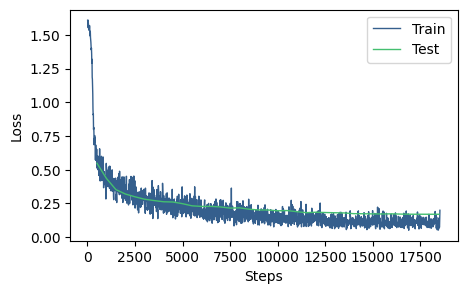

In [14]:
logs = pd.DataFrame(trainer.state.log_history)
llogs = logs.loc[~logs["loss"].isna()]
logs = logs.loc[~logs["eval_loss"].isna()]
# VISUALIZE THE TRAINING PROCESS (LOSS)
plt.figure(figsize=[5,3])
plt.plot(llogs["step"],llogs["loss"],linewidth=1.0,color=plt.get_cmap("viridis")(0.3))
plt.plot(logs["step"],logs["eval_loss"],linewidth=1.0,color=plt.get_cmap("viridis")(0.7))
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend(["Train","Test"])
plt.savefig("final_finetuning_margin_02_temp_01_all.pdf",dpi=300,bbox_inches="tight")

In [ ]:
# 5. Save the final model
model.slide_encoder.save_pretrained("./Agent_resources/Models/final_finetuning")
print("Model saved successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]

Model saved successfully!


In [ ]:
model.query_encoder.save_pretrained("./Agent_resources/Models/final_finetuning_query")
print("Model saved successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.02it/s]

Model saved successfully!
